# Comparação geral das cinco bases
Responsável principal: Sofia Bonini (Integrante 6).

Este notebook consolida o MAE das cinco bases, calcula o ranking dentro de cada base, a quantidade de vitórias e a posição média de cada modelo, consolida o teste de Ljung-Box e os tempos de execução, e exporta as tabelas usadas no relatório.

**Regra do enunciado:** como as bases têm unidades diferentes, os MAEs **não são somados nem calculados em média entre bases**. A comparação entre bases usa apenas posições e vitórias.

Execute somente depois dos cinco pipelines individuais.

In [1]:
from pathlib import Path
import json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
METRICS_DIR = ROOT / 'results' / 'metrics'
RESIDUALS_DIR = ROOT / 'results' / 'residuals'
FIGURES_DIR = ROOT / 'results' / 'figures' / 'comparacao_geral'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOKS_DIR = ROOT / 'notebooks'
OFFICIAL = ['SARIMAX', 'Holt-Winters', 'Random Forest', 'SVR']
BASES = {
    'base_01': ('Bitcoin', 'moeda/BTC', 'diária'),
    'base_02': ('Tráfego I-94', 'veículos/h', 'horária'),
    'base_03': ('PM2.5 Pequim', 'µg/m³', 'horária'),
    'base_04': ('Clima de Jena', '°C', 'diária'),
    'base_05': ('Ouro', 'USD/onça troy', 'semanal'),
}
RANDOM_STATE = 42
rows_mae, rows_lb = [], []

## 1. Validação dos arquivos recebidos

As Bases 01, 02 e 03 exportaram o contrato de saída em `results/`. A Base 04 gravou seus artefatos fora do repositório (`data/raw/base_04/outputs/`), então seus números são lidos das saídas do notebook executado `04_base_04.ipynb`. A Base 05 exportou apenas o modelo final e as previsões do Random Forest; seus MAEs são lidos do notebook executado e complementados na seção 1.2.

In [2]:
esperados = {
    'base_01': [METRICS_DIR / 'base_01_metrics.csv', RESIDUALS_DIR / 'base_01_residuals.csv'],
    'base_02': [METRICS_DIR / 'base_02_metrics.csv', RESIDUALS_DIR / 'base_02_ljung_box.csv'],
    'base_03': [METRICS_DIR / 'base_03_metrics.csv', RESIDUALS_DIR / 'base_03_residuals.csv'],
    'base_04': [NOTEBOOKS_DIR / '04_base_04.ipynb'],
    'base_05': [NOTEBOOKS_DIR / '05_base_05.ipynb', ROOT / 'data/raw/base_05/gold.daily.prices.csv'],
}
display(pd.DataFrame([{'base': b, 'arquivo': str(p.relative_to(ROOT)), 'existe': p.exists()}
                      for b, ps in esperados.items() for p in ps]))
assert all(p.exists() for ps in esperados.values() for p in ps)

def saidas_texto(notebook):
    """Concatena as saídas de texto de um notebook executado."""
    nb = json.loads(Path(notebook).read_text(encoding='utf-8'))
    partes = []
    for cell in nb['cells']:
        for out in cell.get('outputs', []):
            texto = out.get('text') or out.get('data', {}).get('text/plain', '')
            partes.append(''.join(texto))
    return '\n'.join(partes)

,base,arquivo,existe
0,base_01,results/metrics/base_01_metrics.csv,True
1,base_01,results/residuals/base_01_residuals.csv,True
2,base_02,results/metrics/base_02_metrics.csv,True
3,base_02,results/residuals/base_02_ljung_box.csv,True
4,base_03,results/metrics/base_03_metrics.csv,True
5,base_03,results/residuals/base_03_residuals.csv,True
6,base_04,notebooks/04_base_04.ipynb,True
7,base_05,notebooks/05_base_05.ipynb,True
8,base_05,data/raw/base_05/gold.daily.prices.csv,True


### 1.1 Bases 01, 02 e 03: arquivos de métricas e resíduos

In [3]:
m1 = pd.read_csv(METRICS_DIR / 'base_01_metrics.csv')
for r in m1.itertuples():
    rows_mae.append({'base': 'base_01', 'modelo': r.modelo, 'mae': r.mae, 'tempo_s': r.tempo_segundos,
                     'n_avaliado': r.n_teste, 'fonte': 'results/metrics/base_01_metrics.csv'})
    rows_lb.append({'base': 'base_01', 'modelo': r.modelo, 'lag': r.ljung_box_lag,
                    'estatistica': r.ljung_box_stat, 'p_valor': r.ljung_box_pvalue,
                    'fonte': 'results/metrics/base_01_metrics.csv'})

m2 = pd.read_csv(METRICS_DIR / 'base_02_metrics.csv')
for r in m2[m2.escopo == 'oficial'].itertuples():
    rows_mae.append({'base': 'base_02', 'modelo': r.modelo, 'mae': r.mae, 'tempo_s': r.tempo_teste_s,
                     'n_avaliado': r.n_avaliadas, 'fonte': 'results/metrics/base_02_metrics.csv'})
lb2 = pd.read_csv(RESIDUALS_DIR / 'base_02_ljung_box.csv')
for r in lb2[lb2.modelo.isin(OFFICIAL)].itertuples():
    rows_lb.append({'base': 'base_02', 'modelo': r.modelo, 'lag': r.lag, 'estatistica': r.estatistica,
                    'p_valor': r.p_valor, 'fonte': 'results/residuals/base_02_ljung_box.csv'})

m3 = pd.read_csv(METRICS_DIR / 'base_03_metrics.csv')
for r in m3.itertuples():
    rows_mae.append({'base': 'base_03', 'modelo': r.modelo, 'mae': r.MAE, 'tempo_s': r.tempo_segundos,
                     'n_avaliado': r.horas_avaliadas, 'fonte': 'results/metrics/base_03_metrics.csv'})
# O notebook da Base 03 não exportou Ljung-Box; o teste é recalculado sobre os resíduos exportados,
# com os mesmos lags (24 e 48) usados no notebook.
res3 = pd.read_csv(RESIDUALS_DIR / 'base_03_residuals.csv')
for modelo, grupo in res3.groupby('modelo'):
    teste = acorr_ljungbox(grupo.residuo.dropna(), lags=[24, 48], return_df=True)
    for lag, linha in teste.iterrows():
        rows_lb.append({'base': 'base_03', 'modelo': modelo, 'lag': lag, 'estatistica': linha.lb_stat,
                        'p_valor': linha.lb_pvalue, 'fonte': 'recalculado de results/residuals/base_03_residuals.csv'})
print('Bases 01–03 carregadas.')

Bases 01–03 carregadas.


### 1.2 Base 04: saídas do notebook executado

In [4]:
texto4 = saidas_texto(NOTEBOOKS_DIR / '04_base_04.ipynb')
padrao_metricas = re.compile(r'^\d+\s+base_04\s+(SARIMAX|Holt-Winters|Random Forest|SVR|Persistência)\s+'
                             r'(modelo|benchmark)\s+([\d.]+)\s+([\d.]+)\s+(-?[\d.]+)\s*$', re.M)
padrao_tempo = re.compile(r'^\d+\s+(SARIMAX|Holt-Winters|Random Forest|SVR)\s+([\d.]+)\s*$', re.M)
padrao_lb = re.compile(r'^\d+\s+(SARIMAX|Holt-Winters|Random Forest|SVR|Persistência)\s+10\s+'
                       r'([\d.]+)\s+([\d.e+-]+)\s*$', re.M)
metricas4 = {m: float(mae) for m, _, mae, _, _ in padrao_metricas.findall(texto4)}
tempos4 = {m: float(t) for m, t in padrao_tempo.findall(texto4)}
lb4 = {m: (float(s), float(p)) for m, s, p in padrao_lb.findall(texto4)}
assert set(OFFICIAL) <= set(metricas4) and set(OFFICIAL) <= set(tempos4) and set(OFFICIAL) <= set(lb4)
for m in OFFICIAL:
    rows_mae.append({'base': 'base_04', 'modelo': m, 'mae': metricas4[m], 'tempo_s': tempos4[m],
                     'n_avaliado': 767, 'fonte': 'saída de notebooks/04_base_04.ipynb'})
    rows_lb.append({'base': 'base_04', 'modelo': m, 'lag': 10, 'estatistica': lb4[m][0], 'p_valor': lb4[m][1],
                    'fonte': 'saída de notebooks/04_base_04.ipynb'})
referencias = [{'base': 'base_04', 'referencia': 'Persistência (t+1 = t)', 'mae': metricas4['Persistência'],
                'fonte': 'saída de notebooks/04_base_04.ipynb'}]
pd.DataFrame({'MAE (°C)': metricas4})

,MAE (°C)
SVR,1.646800
Random Forest,1.713614
SARIMAX,1.847894
Persistência,1.884335
Holt-Winters,3.436480


### 1.3 Base 05: saídas do notebook e complemento do SARIMAX

O notebook `05_base_05.ipynb` imprimiu o MAE de teste de Holt-Winters, Random Forest e SVR, mas não executou a previsão do SARIMAX no conjunto de teste, apenas a busca e o ajuste final. Para completar a comparação, a célula abaixo reproduz o pipeline da Base 05 com as mesmas regras do notebook (agregação semanal W-SUN, mesmas features, corte 75/25, mesmas grades e `random_state = 42`) e:

1. confere que HW, RF e SVR reproduzem os MAEs impressos no notebook;
2. executa o walk-forward do SARIMAX escolhido, (0,1,1)(0,1,1)<sub>52</sub>, com a função `walk_forward_statsmodels` do notebook (prevê uma semana, incorpora o valor real com `extend`, sem reestimar parâmetros);
3. gera os resíduos de todos os modelos para o Ljung-Box.

O ajuste do SARIMAX leva cerca de 1 minuto.

In [5]:
from time import perf_counter
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

texto5 = saidas_texto(NOTEBOOKS_DIR / '05_base_05.ipynb')
mae_nb5 = [float(v) for v in re.findall(r'MAE no conjunto de teste: ([\d.]+)', texto5)]
mae_nb5 = dict(zip(['Holt-Winters', 'Random Forest', 'SVR'], mae_nb5))
assert len(mae_nb5) == 3, mae_nb5

ouro = pd.read_csv(ROOT / 'data/raw/base_05/gold.daily.prices.csv', sep=r'\s+', na_values='.')
ouro['DATE'] = pd.to_datetime(ouro['DATE'])
semanal = (ouro.set_index('DATE').sort_index().groupby(level=0).mean()
           .resample('W-SUN').mean().ffill().rename(columns={'VALUE': 'alvo'}))
feat = semanal[['alvo']].copy()
for lag in [1, 2, 4, 8, 52]:
    feat[f'alvo_lag_{lag}'] = feat.alvo.shift(lag)
for janela in [4, 12]:
    passado = feat.alvo.shift(1)
    feat[f'media_movel_{janela}'] = passado.rolling(janela).mean()
    feat[f'std_movel_{janela}'] = passado.rolling(janela).std()
mes, semana = semanal.index.month, semanal.index.isocalendar().week.astype(int).to_numpy()
feat['mes_sen'], feat['mes_cos'] = np.sin(2*np.pi*mes/12), np.cos(2*np.pi*mes/12)
feat['semana_sen'], feat['semana_cos'] = np.sin(2*np.pi*semana/52), np.cos(2*np.pi*semana/52)
feat = feat.dropna()
X5, y5 = feat.drop(columns='alvo'), feat.alvo
corte = int(len(feat) * 0.75)
X5_tr, X5_te, y5_tr, y5_te = X5.iloc[:corte], X5.iloc[corte:], y5.iloc[:corte], y5.iloc[corte:]
print(f'Treino: {len(y5_tr)} semanas | Teste: {len(y5_te)} semanas ({y5_te.index.min():%Y-%m-%d} a {y5_te.index.max():%Y-%m-%d})')

prev5, tempo5 = {}, {}
t0 = perf_counter()
hw = ExponentialSmoothing(y5_tr, trend='add', seasonal='add', seasonal_periods=52).fit()
a, b, g = (float(hw.params[k]) for k in ('smoothing_level', 'smoothing_trend', 'smoothing_seasonal'))
nivel, tend = float(hw.level.iloc[-1]), float(hw.trend.iloc[-1])
saz = hw.season.iloc[-52:].tolist(); p = []
for real in y5_te:
    s = saz[0]; p.append(nivel + tend + s)
    novo_nivel = a*(real - s) + (1-a)*(nivel + tend)
    tend = b*(novo_nivel - nivel) + (1-b)*tend
    saz = saz[1:] + [g*(real - novo_nivel) + (1-g)*s]; nivel = novo_nivel
prev5['Holt-Winters'] = np.array(p); tempo5['Holt-Winters'] = perf_counter() - t0

cv = TimeSeriesSplit(n_splits=3)
t0 = perf_counter()
rf = GridSearchCV(RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1),
                  {'max_depth': [8, None], 'min_samples_leaf': [1, 3], 'max_features': ['sqrt', 0.8]},
                  scoring='neg_mean_absolute_error', cv=cv).fit(X5_tr, y5_tr)
prev5['Random Forest'] = rf.best_estimator_.predict(X5_te); tempo5['Random Forest'] = perf_counter() - t0
t0 = perf_counter()
svr = GridSearchCV(make_pipeline(StandardScaler(), SVR(kernel='rbf')),
                   {'svr__C': [1, 10, 100], 'svr__epsilon': [0.05, 0.20], 'svr__gamma': ['scale', 0.01]},
                   scoring='neg_mean_absolute_error', cv=cv).fit(X5_tr, y5_tr)
prev5['SVR'] = svr.best_estimator_.predict(X5_te); tempo5['SVR'] = perf_counter() - t0

t0 = perf_counter()
ajuste = SARIMAX(y5_tr, order=(0, 1, 1), seasonal_order=(0, 1, 1, 52),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=50)
print(f'AIC do SARIMAX final: {ajuste.aic:.2f} (notebook 05: 11970.56)')
atual, p = ajuste, []
for data, real in y5_te.items():
    p.append(float(np.asarray(atual.get_forecast(steps=1).predicted_mean)[0]))
    atual = atual.extend(pd.Series([float(real)], index=pd.DatetimeIndex([data], freq='W-SUN'), name=y5_te.name))
prev5['SARIMAX'] = np.array(p); tempo5['SARIMAX'] = perf_counter() - t0

conferencia = pd.DataFrame({
    'mae_notebook_05': pd.Series(mae_nb5),
    'mae_reproduzido': pd.Series({m: mean_absolute_error(y5_te, v) for m, v in prev5.items()}),
})
display(conferencia)
for m, v in mae_nb5.items():
    assert np.isclose(conferencia.loc[m, 'mae_reproduzido'], v, rtol=2e-3), m

for m in OFFICIAL:
    usa_notebook = m in mae_nb5
    rows_mae.append({'base': 'base_05', 'modelo': m,
                     'mae': mae_nb5[m] if usa_notebook else conferencia.loc[m, 'mae_reproduzido'],
                     'tempo_s': np.nan if usa_notebook else tempo5[m], 'n_avaliado': len(y5_te),
                     'fonte': 'saída de notebooks/05_base_05.ipynb' if usa_notebook
                              else 'walk-forward executado neste notebook (seção 1.3)'})
    teste = acorr_ljungbox(y5_te.values - prev5[m], lags=[10], return_df=True).iloc[0]
    rows_lb.append({'base': 'base_05', 'modelo': m, 'lag': 10, 'estatistica': teste.lb_stat,
                    'p_valor': teste.lb_pvalue, 'fonte': 'resíduos reproduzidos neste notebook (seção 1.3)'})
referencias.append({'base': 'base_05', 'referencia': 'Persistência (t+1 = t)',
                    'mae': mean_absolute_error(y5_te, X5_te['alvo_lag_1']), 'fonte': 'calculado neste notebook'})

Treino: 1762 semanas | Teste: 588 semanas (2003-01-12 a 2014-04-13)


AIC do SARIMAX final: 11970.56 (notebook 05: 11970.56)


,mae_notebook_05,mae_reproduzido
Holt-Winters,15.9903,15.978901
Random Forest,364.9088,364.865088
SARIMAX,NaN,15.588361
SVR,427.0910,427.090994


## 2. Consolidação dos MAEs

In [6]:
mae = pd.DataFrame(rows_mae)
assert mae.groupby('base').modelo.apply(set).eq(set(OFFICIAL)).all(), 'cada base precisa dos quatro modelos oficiais'
tabela_mae = mae.pivot(index='modelo', columns='base', values='mae').loc[OFFICIAL]
tabela_mae.columns = [f'{b} ({BASES[b][1]})' for b in tabela_mae.columns]
display(tabela_mae.round(3))

,base_01 (moeda/BTC),base_02 (veículos/h),base_03 (µg/m³),base_04 (°C),base_05 (USD/onça troy)
modelo,,,,,
SARIMAX,1363.066,290.411,9.945,1.848,15.588
Holt-Winters,1317.714,199.137,10.371,3.436,15.990
Random Forest,1524.472,134.742,9.926,1.714,364.909
SVR,1595.297,143.514,13.716,1.647,427.091


### Referências ingênuas
Comparar com a persistência mostra quanto cada modelo realmente acrescenta. As Bases 02 e 04 calcularam a referência no próprio notebook; nas Bases 01 e 03 ela é recalculada a partir das previsões exportadas (último valor observado antes da origem).

In [7]:
ref2 = pd.read_csv(METRICS_DIR / 'base_02_baseline.csv')
referencias.append({'base': 'base_02', 'referencia': 'Sazonal ingênuo (168 h)',
                    'mae': float(ref2.loc[ref2.modelo.str.startswith('Sazonal'), 'mae_mesmas_datas'].iloc[0]),
                    'fonte': 'results/metrics/base_02_baseline.csv'})
p1 = pd.read_csv(ROOT / 'results/predictions/base_01_predictions.csv')
p1 = p1[p1.modelo == 'SVR'].sort_values('data_prevista')
fech = pd.read_parquet(ROOT / 'data/processed/base_01.parquet').set_index('data_fechamento')['priceClose']
ingenuo1 = fech.reindex(pd.to_datetime(p1.data_origem)).to_numpy()
referencias.append({'base': 'base_01', 'referencia': 'Persistência (t+1 = t)',
                    'mae': float(np.mean(np.abs(p1.valor_real.to_numpy() - ingenuo1))), 'fonte': 'calculado neste notebook'})
p3 = pd.read_csv(ROOT / 'results/predictions/base_03_predictions.csv')
real3 = p3[p3.modelo == 'SVR'].set_index('data_prevista').valor_real
ok = real3.notna() & real3.shift(1).notna()
referencias.append({'base': 'base_03', 'referencia': 'Persistência (t+1 = t)',
                    'mae': float((real3 - real3.shift(1))[ok].abs().mean()), 'fonte': 'calculado neste notebook'})
referencias = pd.DataFrame(referencias).sort_values('base', ignore_index=True)
melhor = mae.loc[mae.groupby('base').mae.idxmin()].set_index('base')
referencias['melhor_modelo'] = referencias.base.map(melhor.modelo)
referencias['mae_melhor'] = referencias.base.map(melhor.mae)
referencias['ganho_sobre_referencia_%'] = 100 * (1 - referencias.mae_melhor / referencias.mae)
display(referencias.round(3))

,base,referencia,mae,fonte,melhor_modelo,mae_melhor,ganho_sobre_referencia_%
0,base_01,Persistência (t+1 = t),1317.332,calculado neste notebook,Holt-Winters,1317.714,-0.029
1,base_02,Sazonal ingênuo (168 h),293.648,results/metrics/base_02_baseline.csv,Random Forest,134.742,54.115
2,base_03,Persistência (t+1 = t),10.339,calculado neste notebook,Random Forest,9.926,4.000
3,base_04,Persistência (t+1 = t),1.884,saída de notebooks/04_base_04.ipynb,SVR,1.647,12.606
4,base_05,Persistência (t+1 = t),16.013,calculado neste notebook,SARIMAX,15.588,2.650


## 3. Ranking dentro de cada base

base,base_01,base_02,base_03,base_04,base_05
modelo,,,,,
SARIMAX,2,4,2,3,1
Holt-Winters,1,3,3,4,2
Random Forest,3,1,1,2,3
SVR,4,2,4,1,4


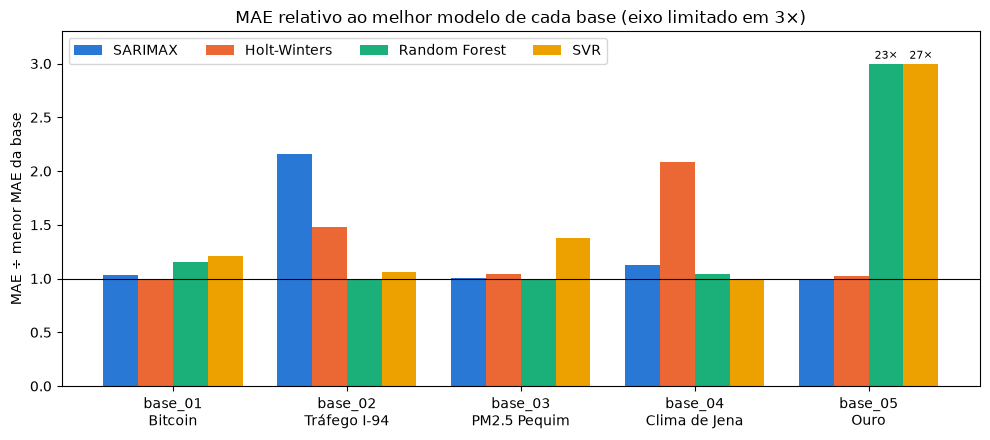

In [8]:
mae['posicao'] = mae.groupby('base').mae.rank(method='min').astype(int)
mae['mae_relativo_ao_melhor'] = mae.mae / mae.groupby('base').mae.transform('min')
ranking = mae.pivot(index='modelo', columns='base', values='posicao').loc[OFFICIAL]
display(ranking)
fig, ax = plt.subplots(figsize=(10, 4.5))
cores = {'SARIMAX': '#2a78d6', 'Holt-Winters': '#eb6834', 'Random Forest': '#1baf7a', 'SVR': '#eda100'}
largura = 0.2
for i, m in enumerate(OFFICIAL):
    valores = mae[mae.modelo == m].set_index('base').loc[list(BASES), 'mae_relativo_ao_melhor']
    barras = ax.bar(np.arange(5) + (i - 1.5) * largura, valores.clip(upper=3), largura, label=m, color=cores[m])
    for x, v in zip(np.arange(5) + (i - 1.5) * largura, valores):
        if v > 3:
            ax.text(x, 3.02, f'{v:.0f}×', ha='center', va='bottom', fontsize=8)
ax.axhline(1, color='black', linewidth=0.8)
ax.set_xticks(range(5), [f'{b}\n{BASES[b][0]}' for b in BASES])
ax.set(ylabel='MAE ÷ menor MAE da base', ylim=(0, 3.3), title='MAE relativo ao melhor modelo de cada base (eixo limitado em 3×)')
ax.legend(ncol=4, loc='upper left')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'mae_relativo.png', dpi=150); plt.show()

## 4. Quantidade de vitórias e 5. Posição média por modelo

In [9]:
consolidado = pd.DataFrame({
    'vitorias': (ranking == 1).sum(axis=1),
    'posicao_media': ranking.mean(axis=1),
    'pior_posicao': ranking.max(axis=1),
}).sort_values(['posicao_media', 'vitorias'], ascending=[True, False])
display(consolidado)

,vitorias,posicao_media,pior_posicao
modelo,,,
Random Forest,2,2.0,3
SARIMAX,1,2.4,4
Holt-Winters,1,2.6,4
SVR,1,3.0,4


## 6. Consolidação do Ljung-Box
`p > 0,05`: sem evidência de autocorrelação remanescente nos resíduos até o lag testado.

In [10]:
ljung = pd.DataFrame(rows_lb)
ljung['sem_autocorrelacao_5pct'] = ljung.p_valor > 0.05
display(ljung.pivot_table(index=['base', 'lag'], columns='modelo', values='p_valor')[OFFICIAL]
        .map(lambda p: f'{p:.3f}' if p >= 0.001 else '<0,001'))
print('Combinações sem autocorrelação a 5%:')
display(ljung[ljung.sem_autocorrelacao_5pct][['base', 'modelo', 'lag', 'estatistica', 'p_valor']])

modelo      SARIMAX Holt-Winters Random Forest     SVR
base    lag                                           
base_01 10   <0,001        0.273        <0,001   0.007
base_02 24   <0,001       <0,001        <0,001  <0,001
        48   <0,001       <0,001        <0,001  <0,001
        168  <0,001       <0,001        <0,001  <0,001
base_03 24   <0,001       <0,001        <0,001  <0,001
        48   <0,001       <0,001        <0,001  <0,001
base_04 10   <0,001       <0,001         0.128   0.055
base_05 10    0.335       <0,001        <0,001  <0,001

Combinações sem autocorrelação a 5%:


,base,modelo,lag,estatistica,p_valor
0,base_01,Holt-Winters,10,12.184963,0.272868
26,base_04,Random Forest,10,15.105236,0.128272
27,base_04,SVR,10,18.025150,0.054541
28,base_05,SARIMAX,10,11.288983,0.335451


## 7. Comparação de tempos de execução
Tempos do teste walk-forward registrados por cada pipeline (sem a busca de hiperparâmetros). Dependem da máquina de cada integrante e servem só para ordem de grandeza. Na Base 05, apenas o SARIMAX foi cronometrado aqui.

In [11]:
display(mae.pivot(index='modelo', columns='base', values='tempo_s').loc[OFFICIAL].round(1))

base,base_01,base_02,base_03,base_04,base_05
modelo,,,,,
SARIMAX,61.9,3615.7,291.0,86.5,48.0
Holt-Winters,47.4,1.3,32.4,14.7,NaN
Random Forest,5365.7,1766.9,91.3,280.2,NaN
SVR,56.2,1838.9,17.1,25.9,NaN


## 8. Análise geral do SVR

In [12]:
svr_resumo = mae[mae.modelo == 'SVR'][['base', 'mae', 'posicao', 'mae_relativo_ao_melhor']].copy()
svr_resumo['base_nome'] = svr_resumo.base.map(lambda b: BASES[b][0])
display(svr_resumo.round(3))

,base,mae,posicao,mae_relativo_ao_melhor,base_nome
3,base_01,1595.297,4,1.211,Bitcoin
5,base_02,143.514,2,1.065,Tráfego I-94
11,base_03,13.716,4,1.382,PM2.5 Pequim
15,base_04,1.647,1,1.000,Clima de Jena
19,base_05,427.091,4,27.398,Ouro


- **Venceu na Base 04 (clima):** temperatura numa faixa estável ao longo dos anos, ciclo anual forte e muitas covariáveis meteorológicas contínuas e correlacionadas. Esse é o cenário em que o kernel RBF combina bem os sinais. O modelo também foi o escolhido na janela de seleção anterior ao teste.
- **2º lugar na Base 02 (tráfego):** combina de forma suave os lags de 1 e 24 h com a hora do dia e fica 6,5% atrás do Random Forest.
- **Último nas Bases 01, 03 e 05:** no Bitcoin e no ouro o teste atinge níveis de preço acima do treino, e o kernel RBF (assim como as árvores) não extrapola, então a previsão volta para a faixa conhecida. Na Base 05 o viés médio é de +425 USD. Na Base 03 o SVR foi treinado com amostra de 8.000 pontos e grade de dois candidatos.

## 9. Conclusões e limitações

In [13]:
for b in BASES:
    sub = mae[mae.base == b].sort_values('mae')
    print(f"{b} ({BASES[b][0]}): vencedor {sub.iloc[0].modelo} | MAE {sub.iloc[0].mae:.3f} {BASES[b][1]} | "
          f"2º {sub.iloc[1].modelo} a {100*(sub.iloc[1].mae/sub.iloc[0].mae-1):.1f}%")
print()
print('Melhor posição média:', consolidado.index[0], f'({consolidado.posicao_media.iloc[0]:.1f})')

base_01 (Bitcoin): vencedor Holt-Winters | MAE 1317.714 moeda/BTC | 2º SARIMAX a 3.4%
base_02 (Tráfego I-94): vencedor Random Forest | MAE 134.742 veículos/h | 2º SVR a 6.5%
base_03 (PM2.5 Pequim): vencedor Random Forest | MAE 9.926 µg/m³ | 2º SARIMAX a 0.2%
base_04 (Clima de Jena): vencedor SVR | MAE 1.647 °C | 2º Random Forest a 4.1%
base_05 (Ouro): vencedor SARIMAX | MAE 15.588 USD/onça troy | 2º Holt-Winters a 2.6%

Melhor posição média: Random Forest (2.0)


- Nenhum modelo vence em todas as bases. O Random Forest é o mais consistente, e cada um dos quatro modelos vence ao menos uma base.
- Com sazonalidade forte e exógenas informativas (tráfego, clima), os modelos de aprendizado de máquina vencem. Com tendência dominante e sazonalidade nula (Bitcoin, ouro), vencem os modelos clássicos que atualizam o nível a cada observação, mas o ganho sobre a persistência fica entre 0% e 3%.
- **Limitações:** frequência, proporção de teste e frequência de reajuste variam entre as bases. Na Base 05, RF e SVR não são reajustados no teste e o SARIMAX foi avaliado neste notebook. Os artefatos da Base 04 não estão versionados; seus números vêm das saídas do notebook executado.

## 10. Exportação das tabelas do relatório

In [14]:
saidas = {
    'consolidado_mae.csv': mae[['base', 'modelo', 'mae', 'posicao', 'mae_relativo_ao_melhor', 'n_avaliado', 'tempo_s', 'fonte']]
                           .sort_values(['base', 'posicao']),
    'consolidado_ranking.csv': ranking.join(consolidado).reset_index(),
    'consolidado_ljung_box.csv': ljung.sort_values(['base', 'modelo', 'lag']),
    'consolidado_referencias.csv': referencias,
}
for nome, tabela in saidas.items():
    tabela.to_csv(METRICS_DIR / nome, index=False)
display(pd.DataFrame({'arquivo': [f'results/metrics/{n}' for n in saidas],
                      'linhas': [len(t) for t in saidas.values()]}))

,arquivo,linhas
0,results/metrics/consolidado_mae.csv,20
1,results/metrics/consolidado_ranking.csv,4
2,results/metrics/consolidado_ljung_box.csv,32
3,results/metrics/consolidado_referencias.csv,5
